# Team ADAstraPerAspera: Milestone P2

## Import required modules

In [ ]:
# Standard Library Imports
import os
import warnings

from dotenv import load_dotenv
import geopandas as gpd
import yaml

# Local Module Imports
from src.scripts.analysis import predictive_models as pm
from src.scripts.analysis.regression_analysis import (
    compute_gene_spatial_stats,
    plot_top_spatial_genes,
)
from src.scripts.preprocessing.geometry import (
    compute_cell_to_plaque_distances,
)
from src.scripts.preprocessing.orchestrators import (
    preprocess_cells_and_expression,
    preprocess_plaques,
)
from src.scripts.preprocessing.partition import (
    compute_pigs_zscores,
    compute_weird_gene_scores,
    plot_gene_distributions,
    plot_weird_gene_panels,
    summarize_genes,
)
from src.scripts.preprocessing.plaque_distance import (
    plot_cell_to_plaque_map_visible,
)
from src.scripts.preprocessing.spatial_trends import (
    assign_distance_bins,
    mean_expression_by_bin,
    plot_gene_trends,
    plot_mean_heatmap,
)
from src.scripts.research_questions.RQ1 import (
    compute_genewise_categorical_anova,
    plot_expression_heatmap,
    plot_gene_expression_by_distance,
    plot_top_genes_by_distance,
    regress_expression_vs_distance,
    summarize_gene_stats,
    summarize_pig_expression_by_distance,
)
from src.scripts.research_questions.RQ2 import (
    analyze_leiden_spatial,
    analyze_plaque_distance,
)
from src.scripts.research_questions.RQ3 import (
    analyze_plaque_distance_effects,
    process_cell_annotations,
)
from src.scripts.research_questions.RQ4 import (
    run_gene_distance_modeling,
)
from src.scripts.visualization.interactive_plots import interactive_comp_pig_regression
from src.scripts.visualization.plots import (
    cell_type_comp_by_dist,
    cellular_comp_by_dist,
    mean_exp_dist,
    pig_comp_heatmap,
    pig_expr_by_dist,
    plot_model_performance,
    plot_multi_gene_signature,
    plot_plaques,
    plot_pred_vs_true,
    plot_residual_figure,
    plot_residual_hist,
    plot_spatial_overlay,
    plot_spatial_residual_map,
    plot_top_gene_importances,
)
from src.utils.logging_utils import logger

warnings.filterwarnings("ignore")

## Set Up Environment Variables

Please create a `.env` file in the root directory of the project and add the following variables:

```
BASE_XENIUM_DIR=your/path/to/xenium/data
```

Afterwards, please load them using the `load_dotenv` function below:

In [ ]:
load_dotenv()

True

Load configs

In [ ]:
# Get absolute path to this notebook's directory
root_dir = os.getcwd()
config_path = os.path.join(root_dir, "configs/column_annotations.yaml")

# Load YAML safely
with open(os.path.realpath(config_path)) as f:
    config_dict = yaml.safe_load(f)
    PIG_GENES = config_dict["PIG_GENES"]
    meta_cols = config_dict["meta_cols"]
    distance_cols = config_dict["distance_cols"]

# Data Preprocessing

1. Define paths and download URLs

In [ ]:
url = "https://cf.10xgenomics.com/samples/xenium/1.4.0/Xenium_V1_FFPE_TgCRND8_17_9_months/Xenium_V1_FFPE_TgCRND8_17_9_months_outs.zip"
BASE_XENIUM_DIR = os.environ["BASE_XENIUM_DIR"]
PATH_TO_DATA_FOLDER = "src/data/Xenium_V1_FFPE_TgCRND8_17_9_months"
PATH_TO_ANNOTATIONS = f"{PATH_TO_DATA_FOLDER}/Alzeimer_xenium_predicted_cell_types_with_ids.csv"
output_dir = f"{BASE_XENIUM_DIR}/Xenium_V1_FFPE_TgCRND8_17_9_months_outs"

2. Stitch cells and expression data; filter out cells using QC metrics

In [ ]:
filtered_combined_df, combined_df_normalized, gene_cols = preprocess_cells_and_expression(
    url, output_dir, PATH_TO_DATA_FOLDER
)



Dataset already downloaded in /Users/alexanders/Desktop/Downloads_Folder//Xenium_V1_FFPE_TgCRND8_17_9_months_outs, skipping.

Loading the data...

Loading cells table from /Users/alexanders/Desktop/Downloads_Folder//Xenium_V1_FFPE_TgCRND8_17_9_months_outs/cells.parquet
Loaded 62268 cells with 10 columns
Loading expression matrix from /Users/alexanders/Desktop/Downloads_Folder//Xenium_V1_FFPE_TgCRND8_17_9_months_outs/cell_feature_matrix.h5
Loaded expression matrix: 62268 cells * 347 genes
Shape of combined_df: (62268, 357)

Investigating the missing values...

Found 0 columns with missing values. 5 columns with the most missing values:

                 column    dtype  n_missing  pct_missing  n_non_missing
0               cell_id   object          0          0.0          62268
1            x_centroid  float64          0          0.0          62268
2            y_centroid  float64          0          0.0          62268
3     transcript_counts    int64          0          0.0          

3. Preprocess plaques by ensuring they are of proper geometric properties


Loading the plaque data...


Loading the brain polygon...

plaques_long: 161,308 vertices | plaques_poly: 1,938 polygons | brain polygon valid: True

Filtering the plaques...

{'n_final': 1828, 'polygons': 1828, 'multipolygons': 0, 'holes_present': 1, 'convex': 1803}
Kept after area cutoff: 1,736 out of 1,828
{'total': 1736, 'convex': 1711, 'non_convex': 25, 'holes_present': 1, 'mean_area': 133.9314068292565, 'in_brain': 1.0}


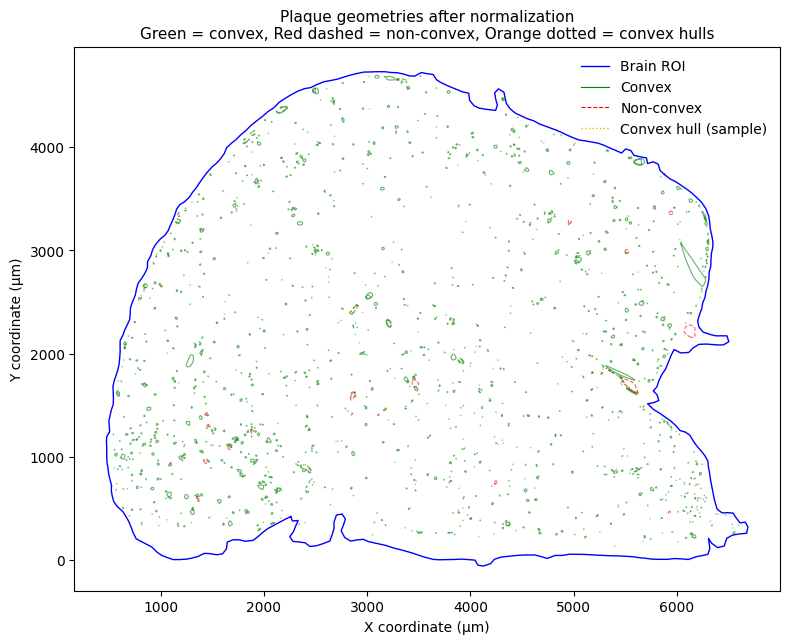

In [ ]:
plaques_poly, brain_geom = preprocess_plaques(PATH_TO_DATA_FOLDER)
logger.info(
    {
        "total": len(plaques_poly),
        "convex": plaques_poly["is_convex"].sum(),
        "non_convex": (~plaques_poly["is_convex"]).sum(),
        "holes_present": plaques_poly["has_holes"].sum(),
        "mean_area": plaques_poly["area"].mean(),
        "in_brain": plaques_poly["in_brain"].mean(),
    }
)
ax = plot_plaques(
    plaques_poly,
    brain_geom=brain_geom if "brain_geom" in globals() else None,
    sample_hulls=20,
    seed=42,
    figsize=(8, 8),
)

4. Using the preprocessed plaques, compute the distance from the cell centroid to the nearest plaque for each cell

In [ ]:
cells_with_distances = compute_cell_to_plaque_distances(filtered_combined_df, plaques_poly)
combined_df_normalized = combined_df_normalized.merge(
    cells_with_distances[
        [
            "cell_id",
            "nearest_plaque_dist",
            "nearest_plaque_center_dist",
            "inside_any_plaque",
            "nearest_plaque_id",
            "nearest_plaque_area",
        ]
    ],
    on="cell_id",
    how="left",
)
logger.info(
    f"Number of cells with missing nearest plaque distance: {combined_df_normalized['nearest_plaque_dist'].isna().sum()}"
)
combined_df_normalized = combined_df_normalized.rename(
    columns={"nearest_plaque_dist": "distance_to_plaque"}
)
cells_with_distances = cells_with_distances.rename(
    columns={"nearest_plaque_dist": "distance_to_plaque"}
)

Computing distances: 100%|█████████████████████████████████| 53895/53895 [00:02<00:00, 19194.53it/s]


{'cells': 53895, 'plaques_used': 1736}
Number of cells with missing nearest plaque distance: 0


# Preliminary Analysis on Preprocessed Data

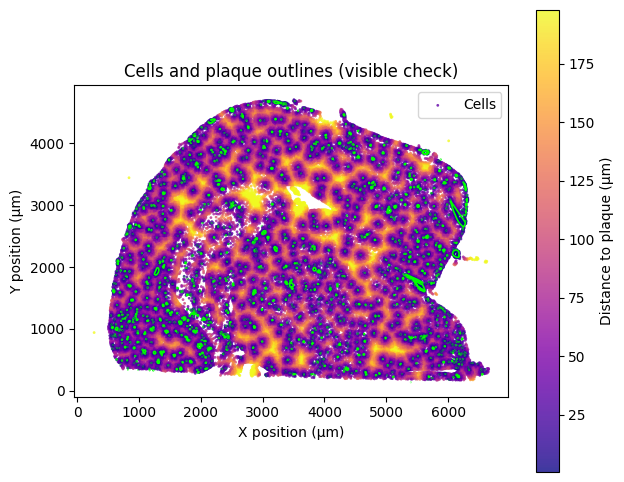

In [ ]:
plot_cell_to_plaque_map_visible(
    combined_df_normalized, gpd.GeoDataFrame({"geometry": plaques_poly["geometry"]})
)

TODOs: 
- Add Error bars
- Explore the 12 other PIGs
- 2010300C02Rik seems suspicious - is it a gene?
- Make bin boundaries decimal
- filter out cells outside the brain polygon

Assigning 6 quantile bins by distance_to_plaque
Computing mean expression per bin


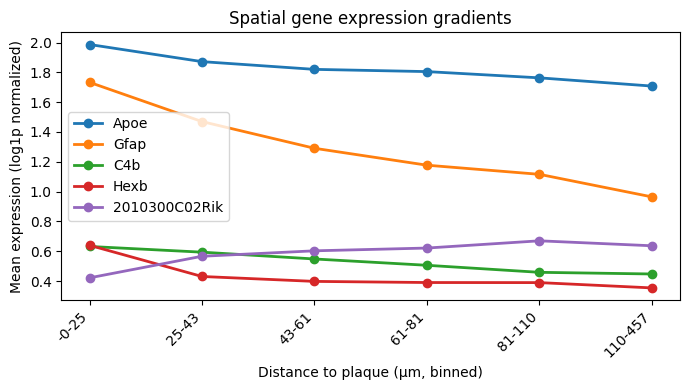

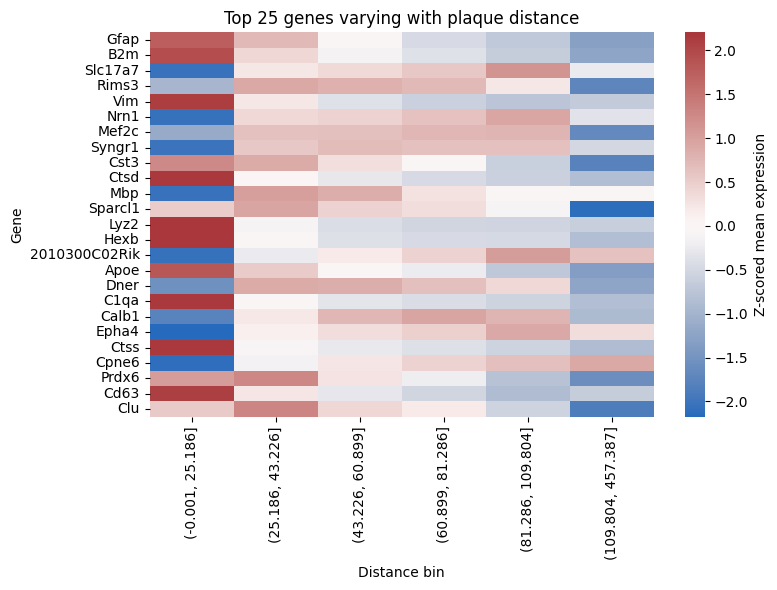

In [ ]:
combined_binned = assign_distance_bins(combined_df_normalized, n_bins=6)
mean_expr = mean_expression_by_bin(combined_binned, gene_cols)
# Plot trends for known PIG genes
plot_gene_trends(mean_expr, ["Apoe", "Gfap", "C4b", "Hexb", "2010300C02Rik"])
# Visualize top genes with spatial gradients
plot_mean_heatmap(mean_expr, top_n=25)

Computed spatial trends for 347 genes (FDR-corrected).


,gene,spearman_r,spearman_p,slope,fdr_pval
251,Ppp1r1b,0.085456,6.723845e-88,0.000950,6.305876e-87
0,2010300C02Rik,0.085246,1.783830e-87,0.001313,1.587151e-86
304,Spag16,0.084551,4.431051e-86,0.000581,3.843937e-85
75,Cpne6,0.081767,1.310929e-80,0.001480,1.109494e-79
187,Mdga1,0.080811,8.991452e-79,0.000496,7.255892e-78
...,...,...,...,...,...
27,C1qa,-0.155922,2.067421e-290,-0.001644,1.434790e-288
340,Vim,-0.170522,0.000000e+00,-0.001964,0.000000e+00
21,B2m,-0.185980,0.000000e+00,-0.002597,0.000000e+00
183,Lyz2,-0.189774,0.000000e+00,-0.001588,0.000000e+00


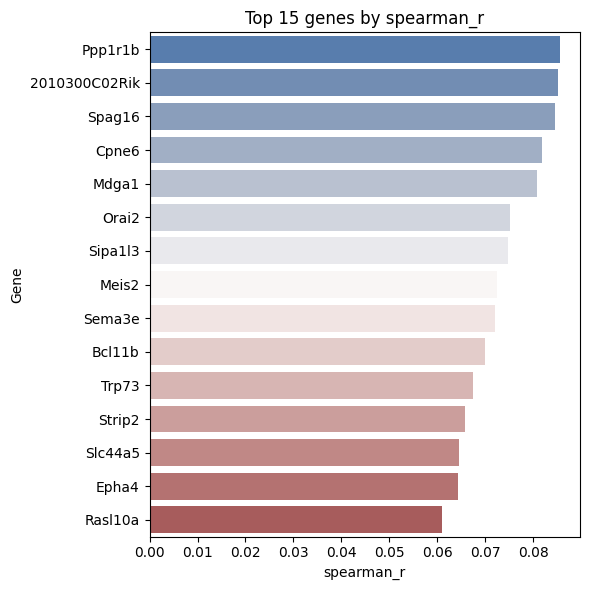

In [ ]:
stats_df = compute_gene_spatial_stats(combined_df_normalized, gene_cols)
significant_genes = stats_df.query("fdr_pval < 0.05")
# filter for significant positive correlations
sig_pos = significant_genes.query("fdr_pval < 0.05")
display(sig_pos)
# visualize only significant ones
plot_top_spatial_genes(sig_pos, top_n=15, metric="spearman_r")

,gene,spearman_r,spearman_p,slope,fdr_pval,abs_spearman_r
50,Cd69,-0.009679,2.464187e-02,-0.000006,3.053832e-02,0.009679
344,Zfp366,-0.010247,1.736734e-02,-0.000037,2.167794e-02,0.010247
329,Tnf,-0.010553,1.428431e-02,-0.000007,1.795890e-02,0.010553
214,Ntng1,-0.010865,1.165494e-02,-0.000377,1.470641e-02,0.010865
309,Sst,-0.011104,9.943934e-03,-0.000106,1.259323e-02,0.011104
...,...,...,...,...,...,...
27,C1qa,-0.155922,2.067421e-290,-0.001644,1.434790e-288,0.155922
340,Vim,-0.170522,0.000000e+00,-0.001964,0.000000e+00,0.170522
21,B2m,-0.185980,0.000000e+00,-0.002597,0.000000e+00,0.185980
183,Lyz2,-0.189774,0.000000e+00,-0.001588,0.000000e+00,0.189774


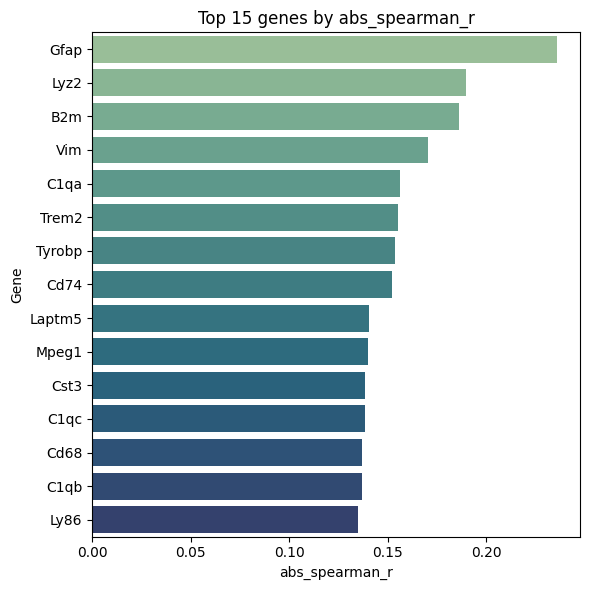

In [ ]:
# filter for significant negative correlations
sig_neg = significant_genes.query("spearman_r < 0")
sig_neg["abs_spearman_r"] = sig_neg["spearman_r"].abs()
display(sig_neg)
plot_top_spatial_genes(sig_neg, top_n=15, metric="abs_spearman_r")

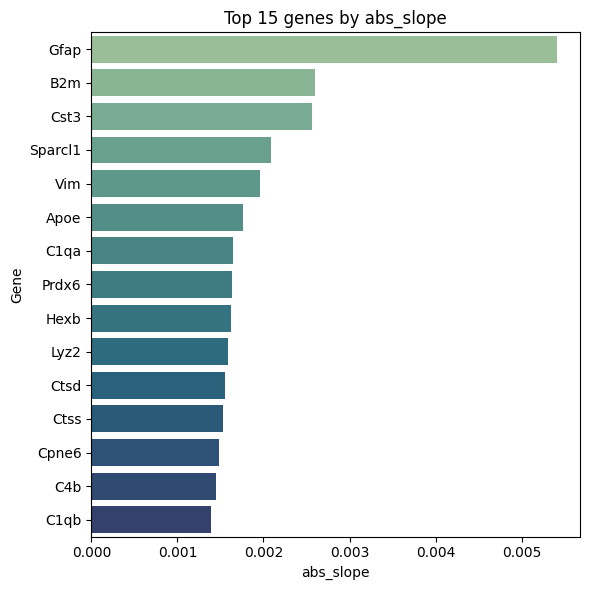

In [ ]:
plot_top_spatial_genes(
    significant_genes.query("gene != 'total_counts'").assign(abs_slope=stats_df["slope"].abs()),
    metric="abs_slope",
    top_n=15,
)

# Exploration on gene expression data

TODO: 
- Is it a good idea to normalize before the analysis below?

In [ ]:
# 1. Compute per-gene summary statistics on filtered cells

g = filtered_combined_df[gene_cols]
summary = summarize_genes(filtered_combined_df[gene_cols])

logger.info(f"Genes summarized: {len(summary):,}")
display(summary.head(10))

Genes summarized: 347


,mean,std,median,mad,skew,kurtosis,nonzero_frac
gene,,,,,,,
2010300C02Rik,1.585305,2.872429,0.0,0.0,3.058556,13.541861,0.444512
Abca7,0.218239,0.548748,0.0,0.0,3.103318,11.923915,0.168012
Acsbg1,0.773337,1.290938,0.0,0.0,2.683205,10.821354,0.407626
Acta2,0.145524,0.805557,0.0,0.0,12.379254,220.505327,0.080620
Acvrl1,0.100492,0.431734,0.0,0.0,5.907066,45.775163,0.068726
Adamts2,0.131144,0.483844,0.0,0.0,5.436704,44.362929,0.092625
Adamtsl1,0.090936,0.351987,0.0,0.0,5.089143,38.896464,0.074961
Adgrl4,0.172799,0.658692,0.0,0.0,5.422771,38.116629,0.095519
Aldh1a2,0.092495,0.642698,0.0,0.0,11.472683,188.234378,0.037907


In [ ]:
# 2. Verify that PIGs are present in the expression data and perform z-normalization for exploration"

pigs_z, info = compute_pigs_zscores(filtered_combined_df, gene_cols)
logger.info(f"PIGs present: {len(info['present'])} | Missing: {info['missing']}")
logger.info(f"Z-scored PIG matrix shape: {pigs_z.shape}")
display(pigs_z.head())

PIGs present: 16 | Missing: []
Z-scored PIG matrix shape: (53895, 16)


,Hexb,Cst3,Cd63,C4b,Ctsd,B2m,H2-K1,Apoe,Gfap,Nrep,Serpina3n,Cd74,Cxcl10,Vim,S100a6,Ifit3
0,-0.494560,0.948647,-0.168951,0.883675,3.507790,0.189909,0.354275,-0.209468,0.352205,4.424604,-0.404441,-0.225795,-0.071031,-0.439027,-0.446673,0.617148
1,0.012388,0.631769,0.402400,-0.601749,-0.046577,1.214806,0.354275,0.230854,0.481630,3.197865,1.780831,-0.225795,-0.071031,0.086851,-0.446673,-0.351437
2,0.012388,0.394111,0.402400,-0.106608,-0.342774,-0.322540,1.312839,1.111499,-0.036067,-0.482354,1.052407,-0.225795,-0.071031,-0.439027,-0.446673,0.617148
3,1.533233,1.344744,2.116452,1.378816,5.581171,3.777050,-0.604289,1.111499,0.611054,6.264713,0.323983,0.762930,-0.071031,0.086851,-0.446673,0.617148
4,0.012388,1.027866,-0.740302,-0.601749,0.545817,-0.834989,0.354275,0.084080,2.681839,3.197865,-0.404441,-0.225795,-0.071031,1.138607,1.847238,-0.351437


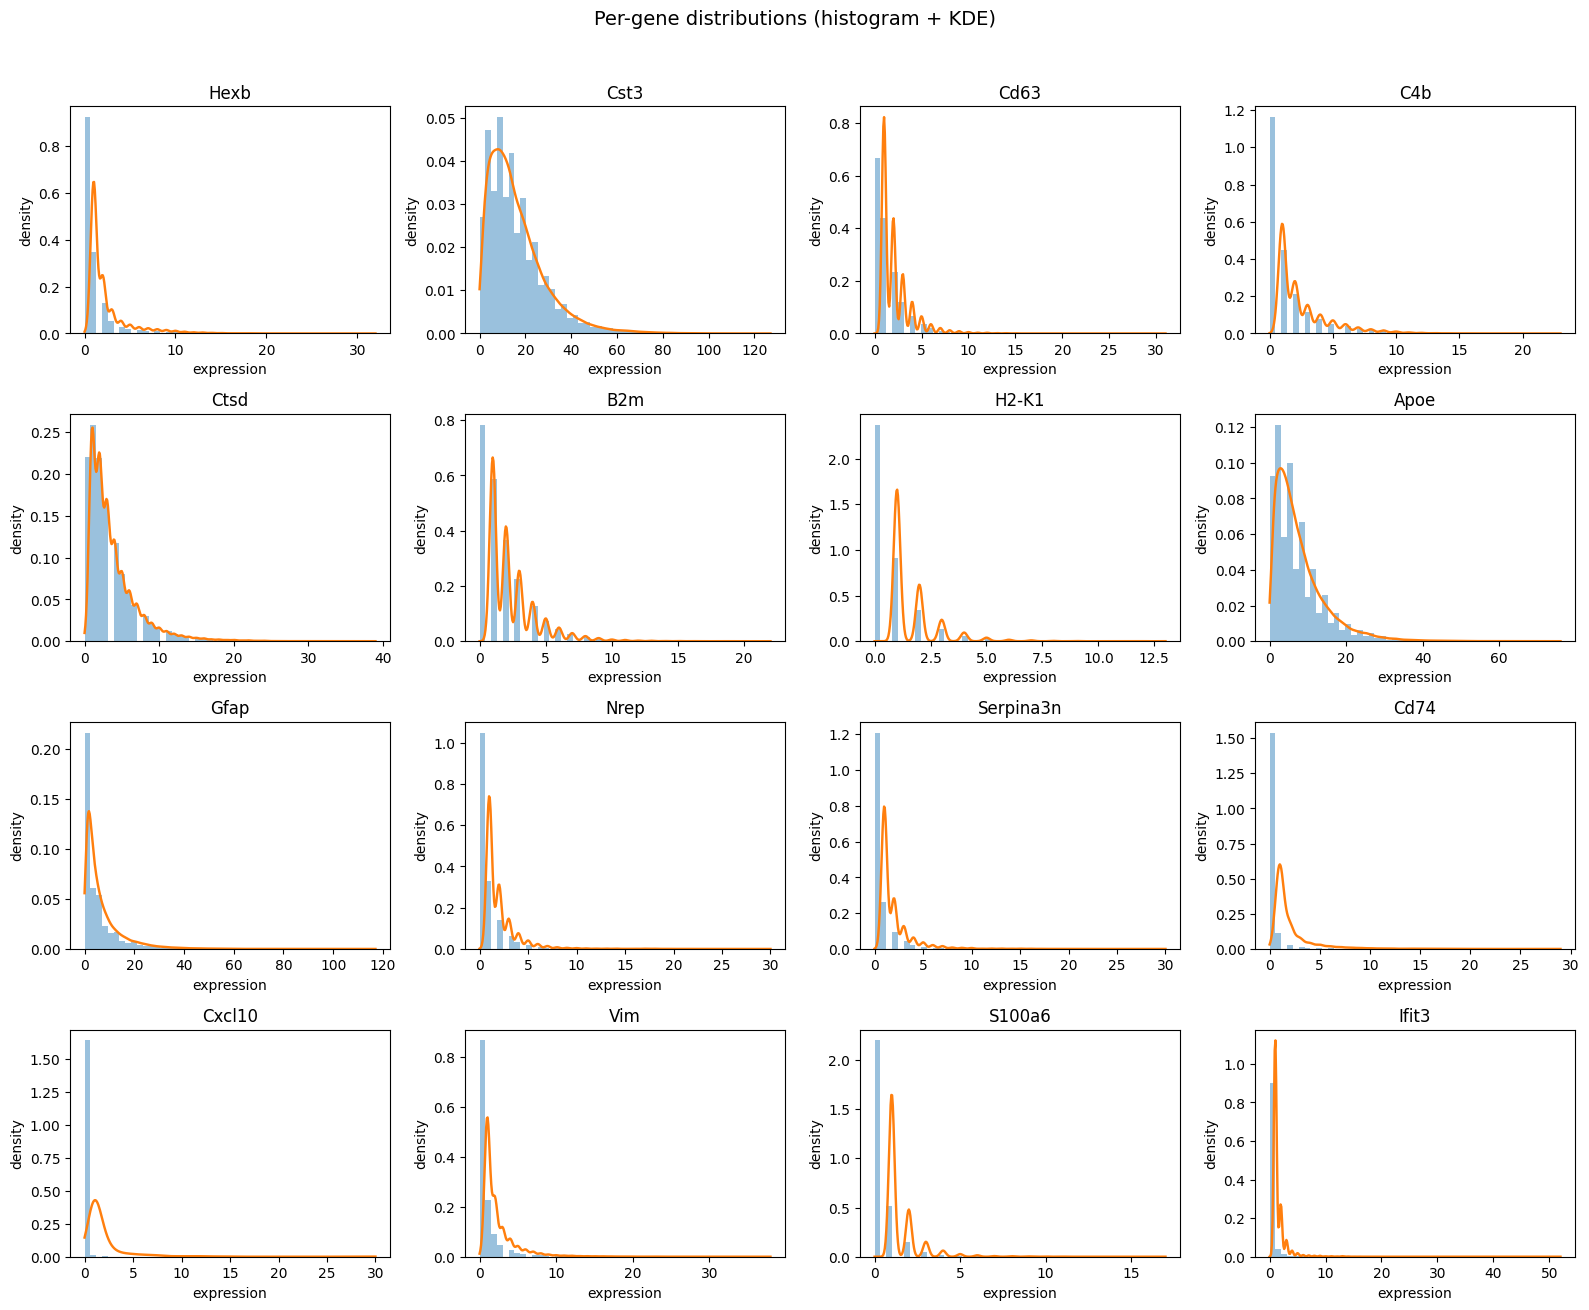

In [ ]:
# 3. Plot the histogram + KDE for PIGs
_ = plot_gene_distributions(filtered_combined_df, genes=info["present"])

In [ ]:
# 4. For each gene, compute its unusualness based on zero-inflation, dispersion, and shape
S, Z = compute_weird_gene_scores(
    filtered_combined_df[gene_cols], clip_z=3.0, ddof_std=0, PIGs=info["present"]
)
logger.info(f"Genes evaluated: {len(S):,}")
logger.info("\nTop 20 by WEIRD SCORE")
display(S.head(20))
logger.info("\nTop 10 by ZERO FRAC")
display(
    S.sort_values("zero_frac", ascending=False).head(10)[
        ["isPIG", "zero_frac", "mean", "cv", "skew", "kurtosis"]
    ]
)
logger.info("\nTop 10 by |SKEW|")
display(
    S.reindex(S["skew"].abs().sort_values(ascending=False).head(10).index)[
        ["isPIG", "skew", "kurtosis", "zero_frac", "cv"]
    ]
)
logger.info("\nTop 10 by KURTOSIS")
display(
    S.sort_values("kurtosis", ascending=False).head(10)[
        ["isPIG", "kurtosis", "skew", "zero_frac", "cv"]
    ]
)

Genes evaluated: 347

Top 20 by WEIRD SCORE


,zero_frac,nonzero_frac,mean,std,cv,skew,kurtosis,q10,q90,tail_ratio,isPIG,weird_score
Tnf,0.997940,0.002060,0.002227,0.059955,26.927410,72.725511,9587.901700,0.0,0.0,1.0,False,9.428883
Chat,0.994860,0.005140,0.006494,0.123026,18.944303,61.862467,7137.261019,0.0,0.0,1.0,False,9.413116
Cxcl10,0.985861,0.014139,0.027776,0.391045,14.078404,36.332878,2017.429800,0.0,0.0,1.0,True,9.211140
Slc6a3,0.997532,0.002468,0.002987,0.067906,22.731506,32.874628,1507.098365,0.0,0.0,1.0,False,8.500838
Lcn2,0.997922,0.002078,0.002356,0.055948,23.742640,31.765245,1425.312232,0.0,0.0,1.0,False,8.379425
Th,0.985045,0.014955,0.028778,0.366274,12.727484,29.023833,1190.082336,0.0,0.0,1.0,False,7.666800
Cort,0.977864,0.022136,0.033194,0.342104,10.306151,28.137388,1253.944920,0.0,0.0,1.0,False,6.976647
Cd69,0.997792,0.002208,0.002208,0.046937,21.257920,21.211469,447.943040,0.0,0.0,1.0,False,6.150916
Nme8,0.995974,0.004026,0.004230,0.068249,16.132695,17.674773,362.083865,0.0,0.0,1.0,False,5.473340
Dkk2,0.993858,0.006142,0.006661,0.088131,13.230733,15.033796,269.558785,0.0,0.0,1.0,False,4.784686



Top 10 by ZERO FRAC


,isPIG,zero_frac,mean,cv,skew,kurtosis
Tnf,False,0.997940,0.002227,26.927410,72.725511,9587.901700
Lcn2,False,0.997922,0.002356,23.742640,31.765245,1425.312232
Cd69,False,0.997792,0.002208,21.257920,21.211469,447.943040
Slc6a3,False,0.997532,0.002987,22.731506,32.874628,1507.098365
Nme8,False,0.995974,0.004230,16.132695,17.674773,362.083865
Chat,False,0.994860,0.006494,18.944303,61.862467,7137.261019
Dkk2,False,0.993858,0.006661,13.230733,15.033796,269.558785
Ptx3,False,0.991595,0.008906,11.339809,14.000458,292.015996
Tgm1,False,0.990259,0.011615,11.265150,16.348204,400.986170
Crh,False,0.986882,0.021820,11.066071,17.465443,408.090353



Top 10 by |SKEW|


,isPIG,skew,kurtosis,zero_frac,cv
Tnf,False,72.725511,9587.901700,0.997940,26.927410
Chat,False,61.862467,7137.261019,0.994860,18.944303
Cxcl10,True,36.332878,2017.429800,0.985861,14.078404
Slc6a3,False,32.874628,1507.098365,0.997532,22.731506
Lcn2,False,31.765245,1425.312232,0.997922,23.742640
Th,False,29.023833,1190.082336,0.985045,12.727484
Cort,False,28.137388,1253.944920,0.977864,10.306151
Cd69,False,21.211469,447.943040,0.997792,21.257920
Nts,False,19.263740,497.488700,0.967993,9.714287
Ebf3,False,19.153784,646.190699,0.977939,9.008545



Top 10 by KURTOSIS


,isPIG,kurtosis,skew,zero_frac,cv
Tnf,False,9587.901700,72.725511,0.997940,26.927410
Chat,False,7137.261019,61.862467,0.994860,18.944303
Cxcl10,True,2017.429800,36.332878,0.985861,14.078404
Slc6a3,False,1507.098365,32.874628,0.997532,22.731506
Lcn2,False,1425.312232,31.765245,0.997922,23.742640
Cort,False,1253.944920,28.137388,0.977864,10.306151
Th,False,1190.082336,29.023833,0.985045,12.727484
Ebf3,False,646.190699,19.153784,0.977939,9.008545
Nts,False,497.488700,19.263740,0.967993,9.714287
Chodl,False,482.664371,18.214106,0.981909,9.861996


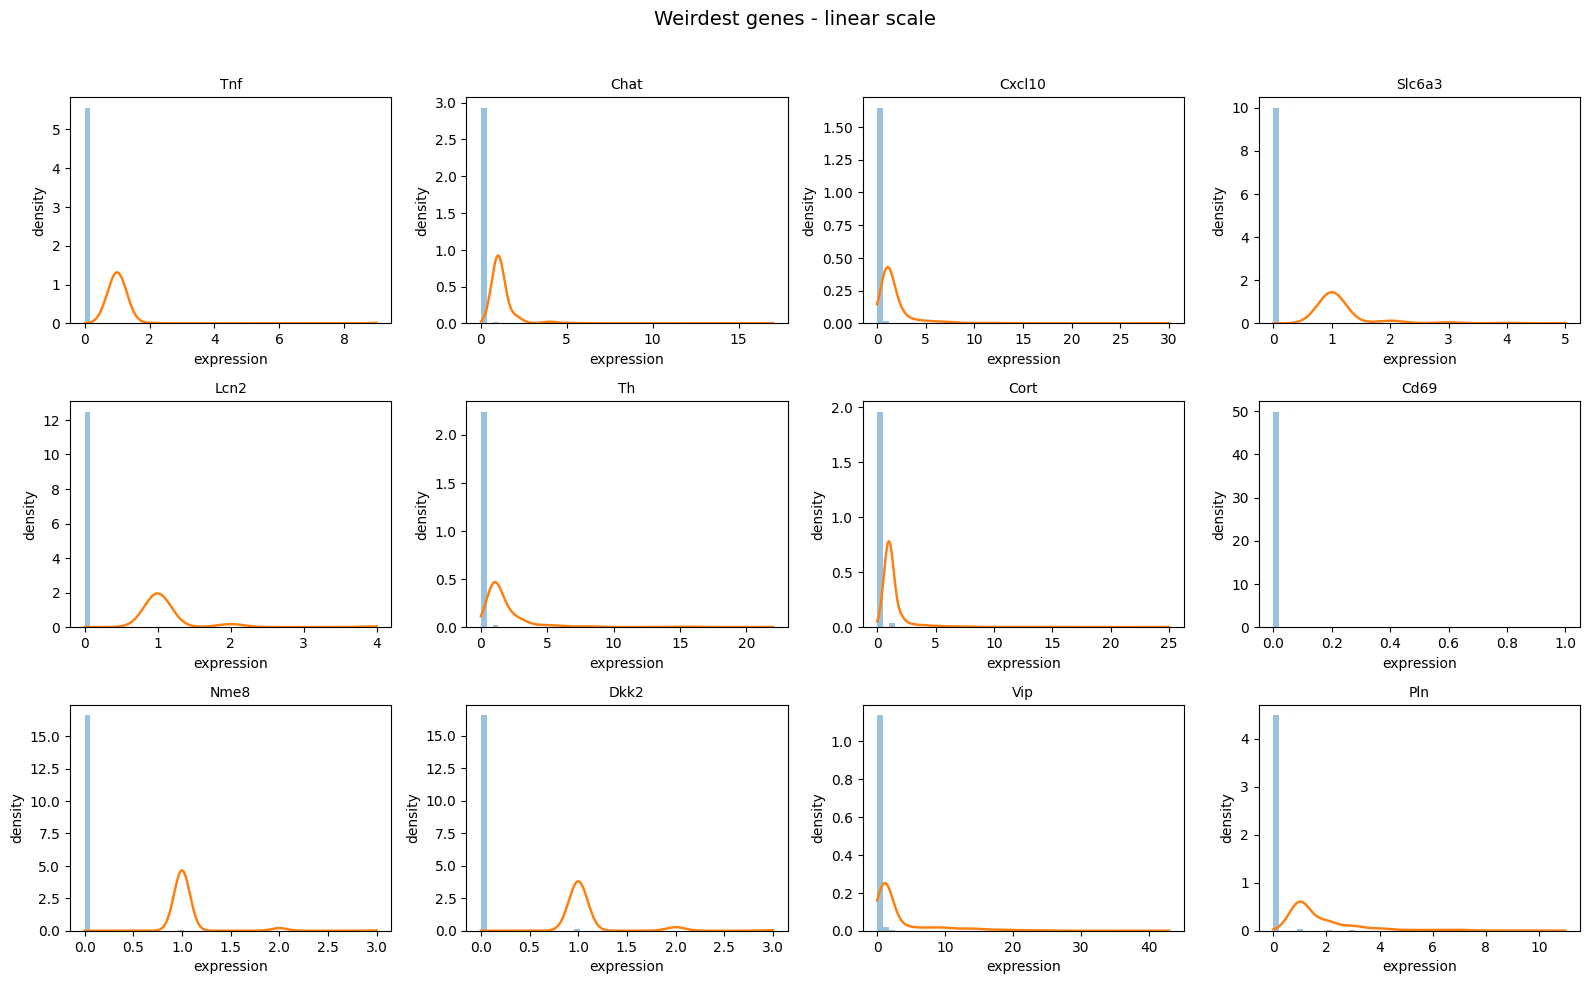

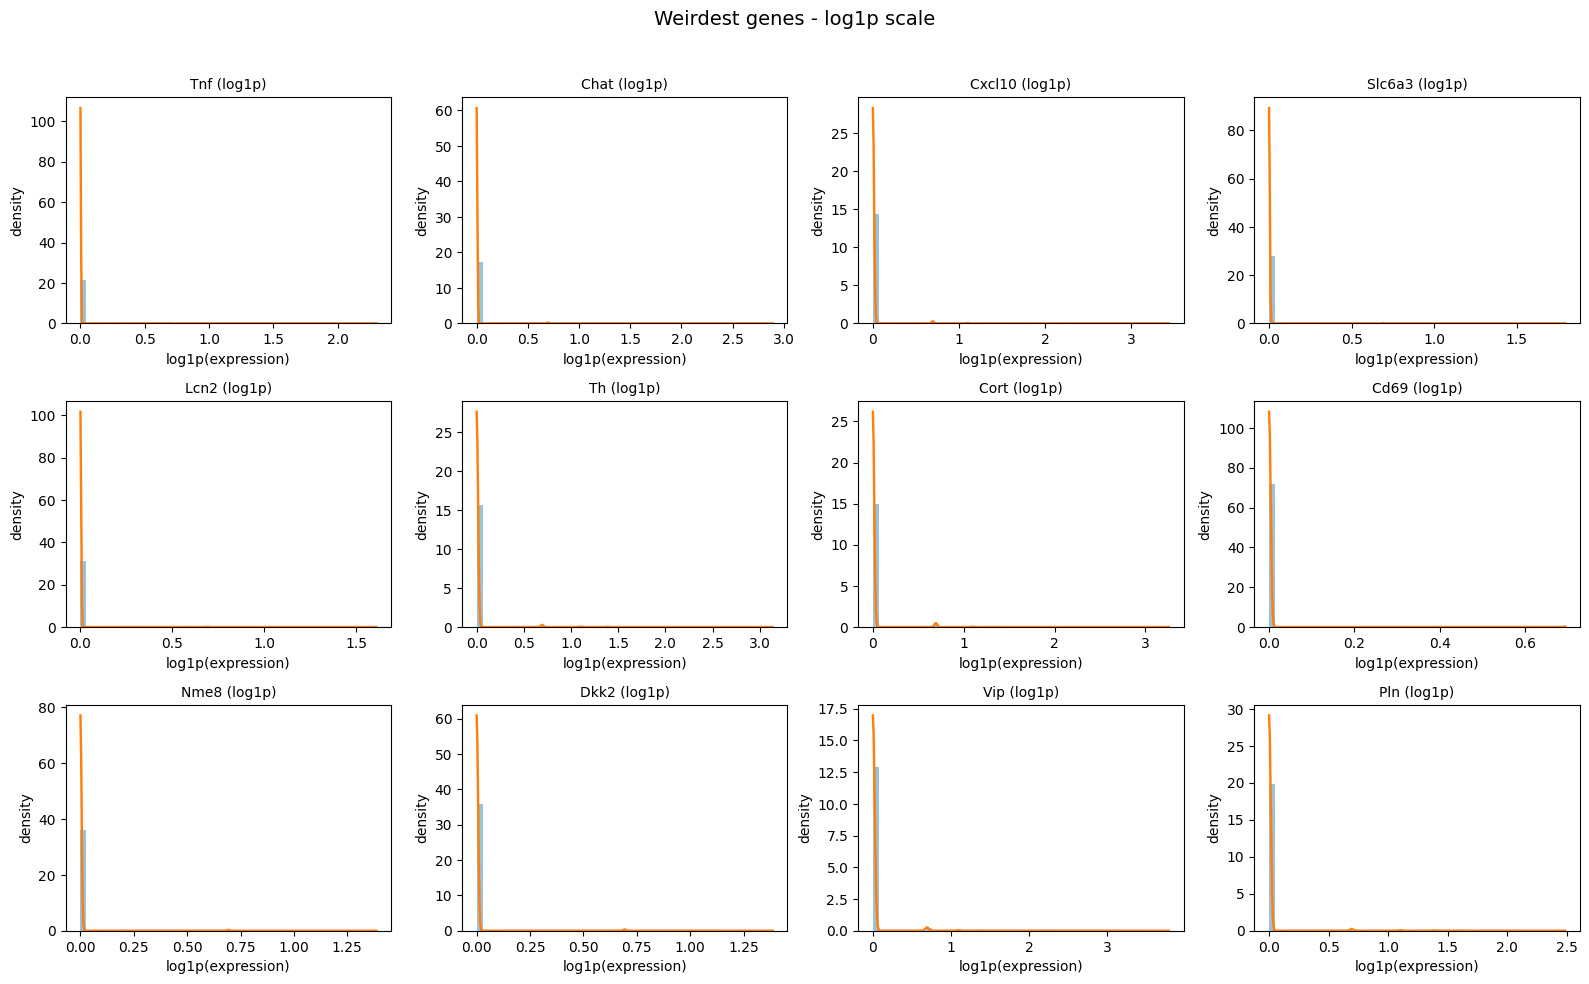

(<Figure size 1600x960 with 12 Axes>, <Figure size 1600x960 with 12 Axes>)

In [ ]:
# 5. Plot the historgram and KDE for weirdest genes (linear and log1p)

genes_to_plot = S.head(12).index.tolist()

plot_weird_gene_panels(
    filtered_combined_df,
    genes_to_plot,
    bins=50,
    cols=4,
    show=True,
)

Research Question 1 — Plaque-Induced Gene (PIG) Expression Gradients

1. Bin cells by distance and compute average PIG expression

In [ ]:
summary_df, counts = summarize_pig_expression_by_distance(combined_df_normalized, PIG_GENES)
logger.info("Mean ± SEM of PIG expression by distance bin:")
display(summary_df.head(15))

# Also check how many cells fall into each bin
logger.info("\nCell counts per distance bin:")
display(counts)

Mean ± SEM of PIG expression by distance bin:


,distance_bin,gene,mean_expr,sem_expr
0,0–20 µm,Hexb,0.699721,0.009625
1,20–50 µm,Hexb,0.430123,0.004877
2,50–100 µm,Hexb,0.390320,0.003966
3,100–200 µm,Hexb,0.363211,0.005218
4,>200 µm,Hexb,0.387021,0.022809
5,0–20 µm,Cst3,2.695902,0.009913
6,20–50 µm,Cst3,2.645646,0.006452
7,50–100 µm,Cst3,2.541654,0.005441
8,100–200 µm,Cst3,2.395390,0.007776
9,>200 µm,Cst3,2.103496,0.035161



Cell counts per distance bin:


distance_bin
0–20 µm        6683
20–50 µm      14711
50–100 µm     20895
100–200 µm    11106
>200 µm         500
Name: count, dtype: int64

2. Visualize Expression vs Distance

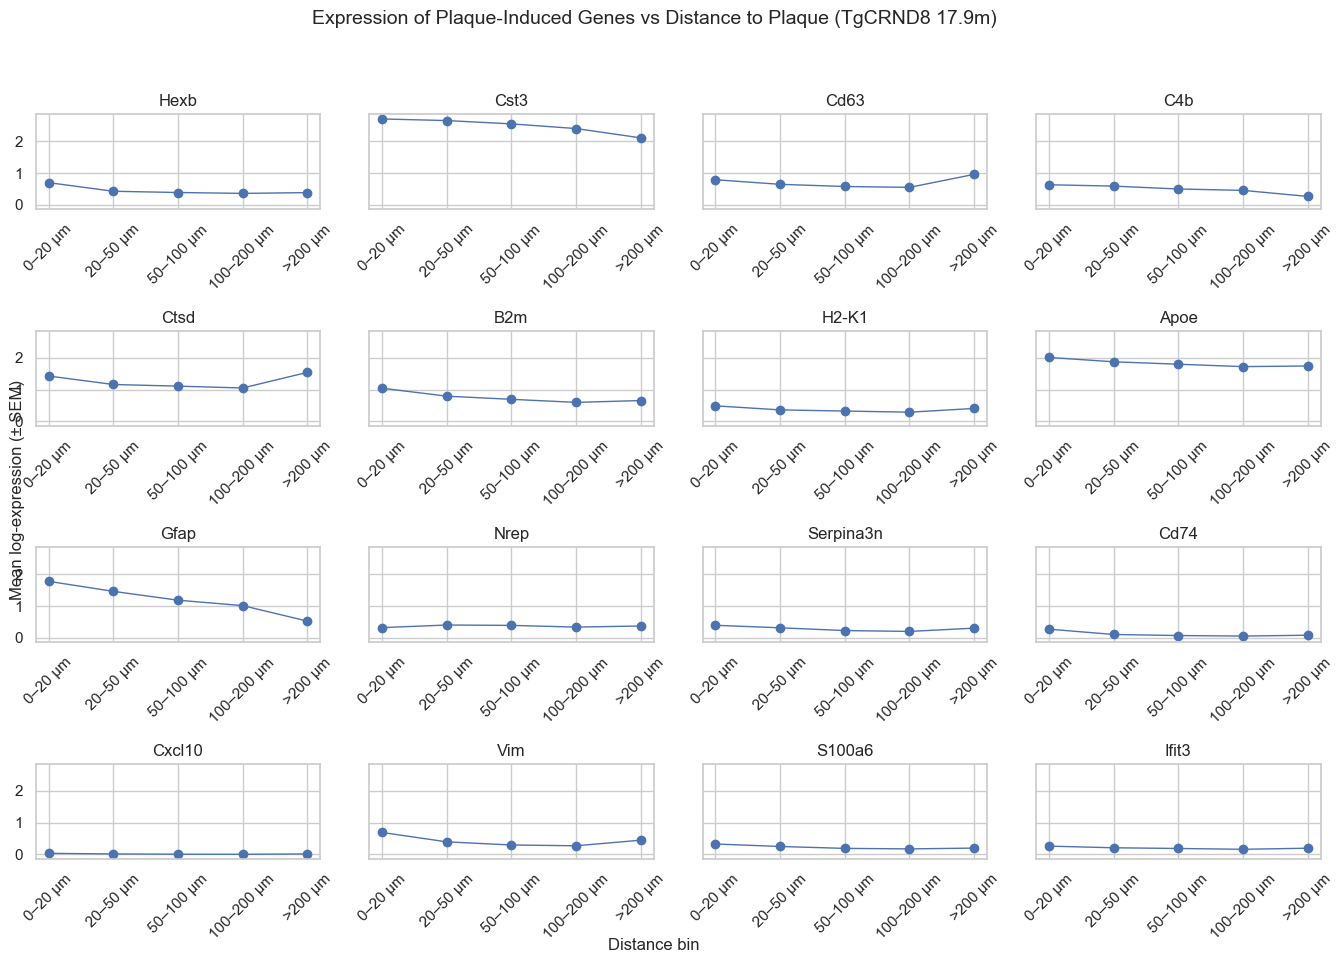

In [ ]:
_ = plot_gene_expression_by_distance(
    summary_df,
    PIG_GENES,
    n_cols=4,
    show=True,
)

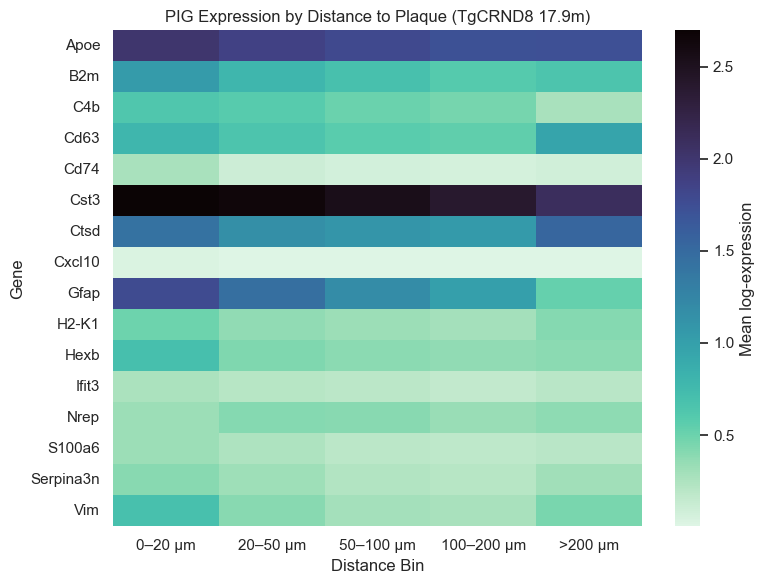

In [ ]:
_ = plot_expression_heatmap(summary_df)

proximal plaques show elevated microglial (Hexb, Ctsd, Cst3, Apoe) and astrocytic (Gfap, Serpina3n, Vim) expression that fades with distance.

Step 4a — Continuous model: per-gene linear regression

In [ ]:
reg_df, proximal_genes = regress_expression_vs_distance(
    combined_df_normalized, PIG_GENES, logger=logger
)
logger.info("Continuous regression results (expression ~ distance):")
display(reg_df)

# Highlight top plaque-proximal genes (negative slope)
proximal_genes = reg_df[reg_df["slope"] < 0].sort_values("qval").head(10)
logger.info("\nTop plaque-proximal genes (negative slope, smallest q-values):")
display(proximal_genes)

Continuous regression results (expression ~ distance).
Computed 16 gene regressions.
Top plaque-proximal genes (negative slope, smallest q-values): 10 returned.
Continuous regression results (expression ~ distance):


,gene,slope,pval,qval
8,Gfap,-0.005408,0.000000e+00,0.000000e+00
5,B2m,-0.002597,0.000000e+00,0.000000e+00
1,Cst3,-0.002562,6.287627e-240,2.515051e-239
13,Vim,-0.001964,2.713979e-261,1.447455e-260
7,Apoe,-0.001763,1.218245e-109,1.949192e-109
0,Hexb,-0.001622,2.067871e-165,5.514323e-165
4,Ctsd,-0.001556,7.925067e-105,1.152737e-104
3,C4b,-0.001445,5.028431e-112,1.005686e-111
10,Serpina3n,-0.001202,6.635228e-139,1.516624e-138
11,Cd74,-0.001027,1.634044e-209,5.228941e-209



Top plaque-proximal genes (negative slope, smallest q-values):


,gene,slope,pval,qval
8,Gfap,-0.005408,0.000000e+00,0.000000e+00
5,B2m,-0.002597,0.000000e+00,0.000000e+00
13,Vim,-0.001964,2.713979e-261,1.447455e-260
1,Cst3,-0.002562,6.287627e-240,2.515051e-239
11,Cd74,-0.001027,1.634044e-209,5.228941e-209
0,Hexb,-0.001622,2.067871e-165,5.514323e-165
10,Serpina3n,-0.001202,6.635228e-139,1.516624e-138
3,C4b,-0.001445,5.028431e-112,1.005686e-111
14,S100a6,-0.000885,3.523692e-110,6.264341e-110
7,Apoe,-0.001763,1.218245e-109,1.949192e-109


Each slope shows how much the log-expression changes per micron away from a plaque. Gene expression decreases as you move away from plaques — consistent with microglial/astrocytic activation. Top genes: Gfap, Cst3, Apoe, Hexb, Serpina3n, Vim are canonical plaque-induced genes
Slopes are small but consistent (−0.001 to −0.005) Because the unit is µm; a 100 µm shift corresponds to roughly 0.1–0.5 log change. Nrep, Ifit3, Cxcl10 show weak slopes so these genes are less spatially patterned.

Step 4b — Categorical model (ANOVA-style)

TODO: logger and display mismatch!

In [ ]:
anova_df = compute_genewise_categorical_anova(combined_binned, PIG_GENES)
logger.info("Categorical ANOVA results (expression ~ distance_bin):")
display(anova_df.head(10))

Categorical ANOVA results (expression ~ distance_bin):


,gene,anova_pval,qval
0,B2m,0.000000e+00,0.000000e+00
1,Gfap,0.000000e+00,0.000000e+00
2,Cd74,0.000000e+00,0.000000e+00
3,Vim,0.000000e+00,0.000000e+00
4,Hexb,1.045064e-280,3.344204e-280
5,Ctsd,4.236198e-228,1.129653e-227
6,Cst3,1.362502e-216,3.114290e-216
7,Serpina3n,8.353140e-206,1.670628e-205
8,S100a6,4.571924e-179,8.127865e-179
9,Cd63,3.054774e-162,4.887639e-162


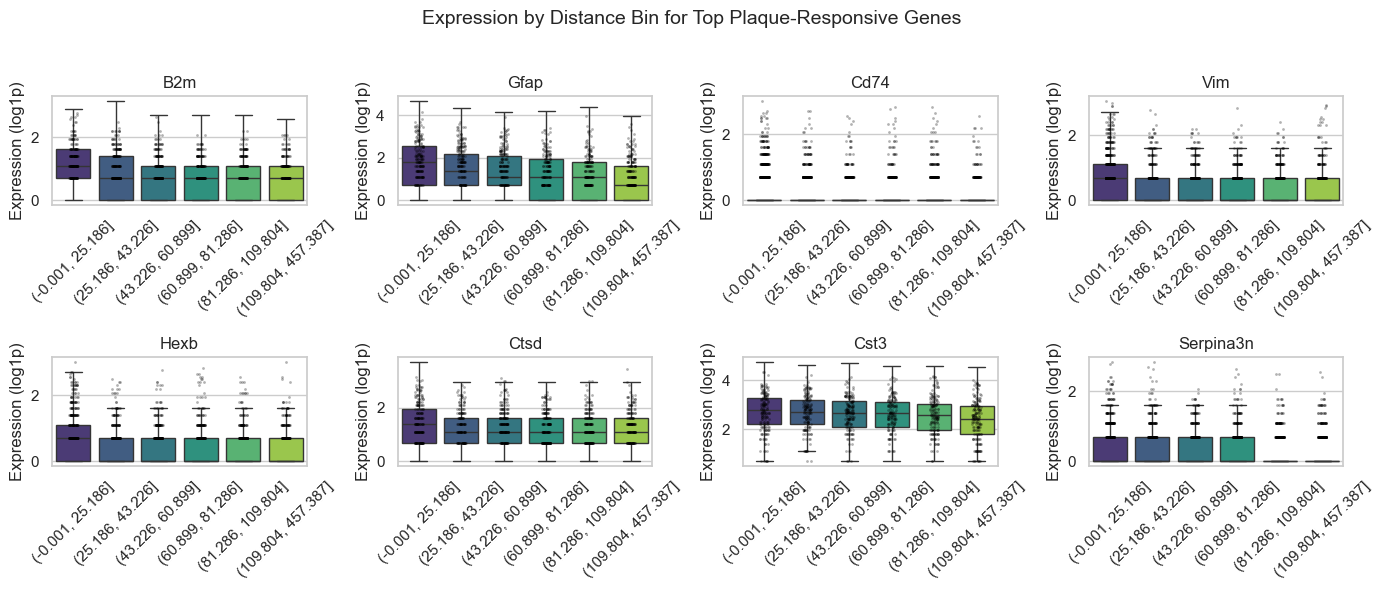

In [ ]:
top_genes = plot_top_genes_by_distance(anova_df, combined_binned)

In [ ]:
summary_stats, top_df, bottom_df = summarize_gene_stats(
    reg_df, anova_df, logger=logger, display_fn=display
)

=== Top plaque-proximal genes (negative slope, smallest q-values) ===


,gene,slope,pval_continuous,qval_continuous,anova_pval,qval_anova
0,Gfap,-0.005408,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
1,B2m,-0.002597,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
2,Cst3,-0.002562,6.287627e-240,2.515051e-239,1.362502e-216,3.114290e-216
3,Vim,-0.001964,2.713979e-261,1.447455e-260,0.000000e+00,0.000000e+00
4,Apoe,-0.001763,1.218245e-109,1.949192e-109,1.495253e-132,1.993671e-132
5,Hexb,-0.001622,2.067871e-165,5.514323e-165,1.045064e-280,3.344204e-280
6,Ctsd,-0.001556,7.925067e-105,1.152737e-104,4.236198e-228,1.129653e-227
7,C4b,-0.001445,5.028431e-112,1.005686e-111,1.258520e-118,1.548947e-118
8,Serpina3n,-0.001202,6.635228e-139,1.516624e-138,8.353140e-206,1.670628e-205
9,Cd74,-0.001027,1.634044e-209,5.228941e-209,0.000000e+00,0.000000e+00



=== Least plaque-responsive genes (weakest or flat slopes) ===


,gene,slope,pval_continuous,qval_continuous,anova_pval,qval_anova
11,Cd63,-0.000977,3.424795e-60,4.215133e-60,3.054774e-162,4.887639e-162
12,S100a6,-0.000885,3.523692e-110,6.264341e-110,4.571924e-179,8.127865e-179
13,Ifit3,-0.000562,1.533243e-47,1.752278e-47,4.659577e-64,4.970216e-64
14,Nrep,-0.000190,4.693449e-04,4.693449e-04,2.494887e-25,2.494887e-25
15,Cxcl10,-0.000157,9.331056e-40,9.953127e-40,5.583195e-65,6.380794e-65


Research Question 2 — Cell Type Frequency Gradients

Identify gene columns and build a clustering matrix

=== Distance to nearest plaque (µm) summary ===
count    53895.000000
mean        68.011376
std         44.416354
min          0.000000
25%         34.454704
50%         60.899394
75%         93.897216
max        457.386841
Name: distance_to_plaque, dtype: float64


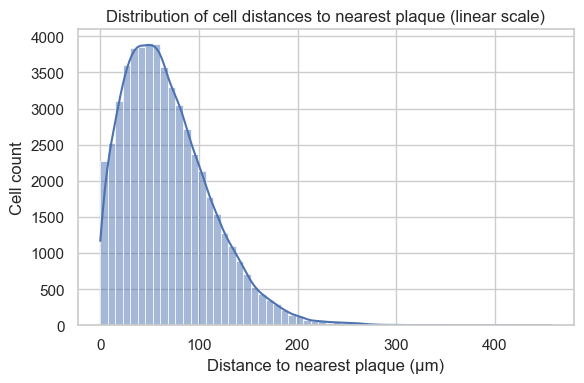

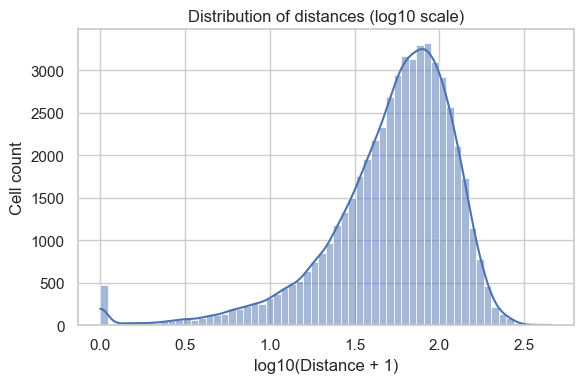

{'5%': 9.035547740783652, '25%': 34.4547036750835, '50% (median)': 60.89939421384185, '75%': 93.89721578622297, '95%': 149.8000085870341}

=== Cell counts by proximity class ===
dist_bin_simple
proximal (<30 µm)           11257
intermediate (30–100 µm)    31032
distal (>100 µm)            11606
Name: count, dtype: int64


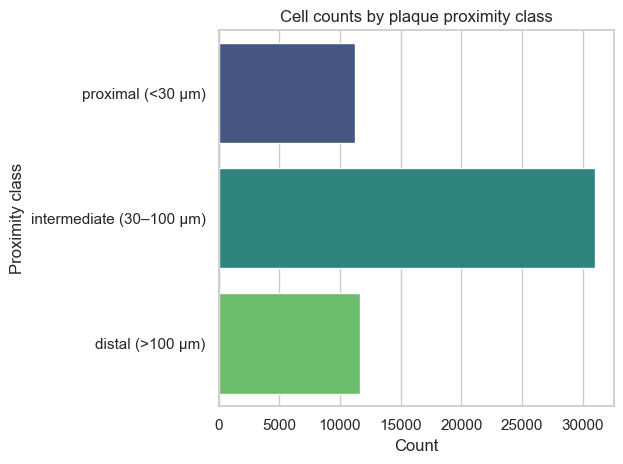

In [ ]:
results = analyze_plaque_distance(
    combined_df_normalized,
    column="distance_to_plaque",
)

Slope < 0	Cluster becomes more common near plaques (enriched proximally).
Slope > 0	Cluster becomes less common near plaques (enriched distally).

- TODO: replace cluster IDs with the ground truth labels

Detected 347 gene columns
AnnData created with shape (53895, 347)
=== PCA → Neighbors → Leiden Clustering ===
Leiden cluster counts:
leiden
0     9793
1     6445
2     5732
3     4287
4     3871
5     3734
6     2427
7     2073
8     2029
9     1865
10    1630
11    1568
12    1531
13    1300
14    1168
15    1070
16     954
17     737
18     604
19     505
20     400
21     172
Name: count, dtype: int64


... storing 'dist_bin_simple' as categorical


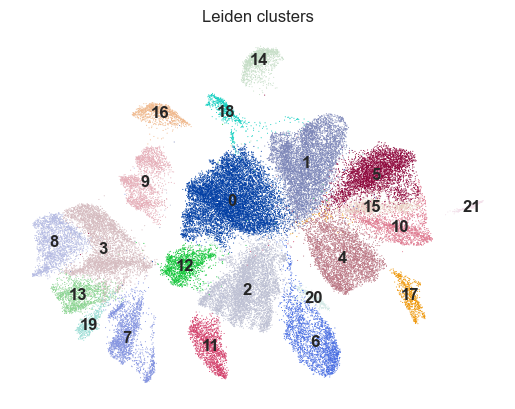

Added 'cluster_leiden' column to dataframe.


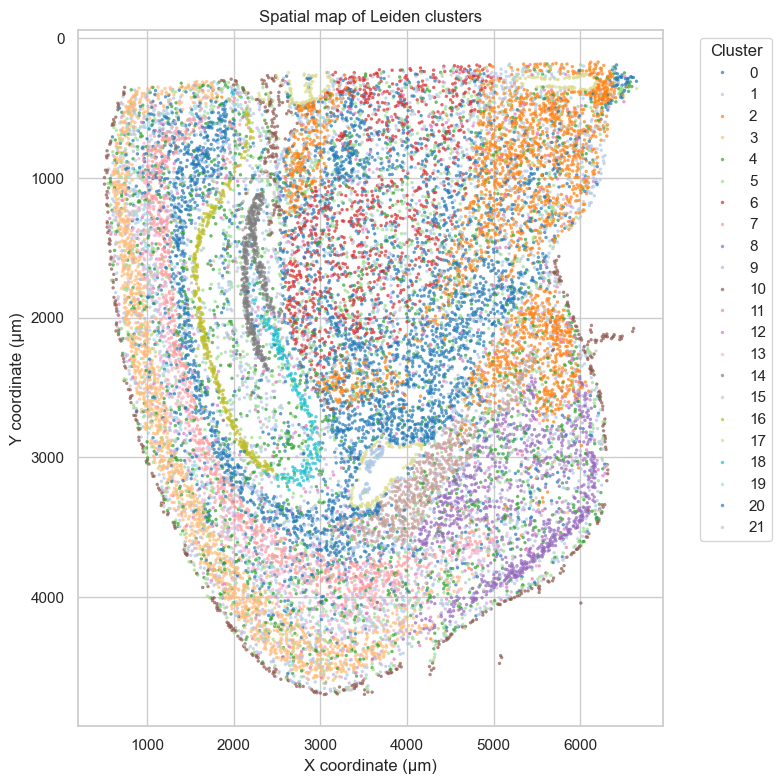

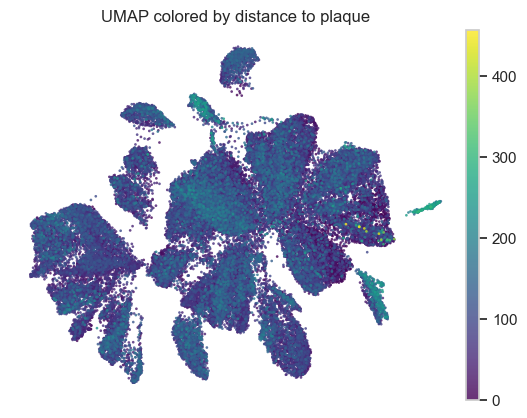

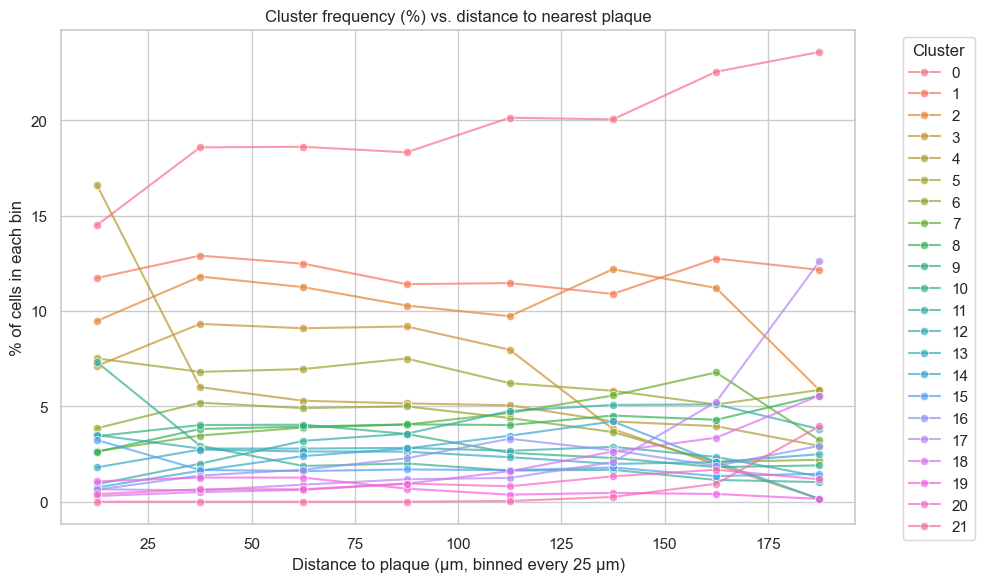

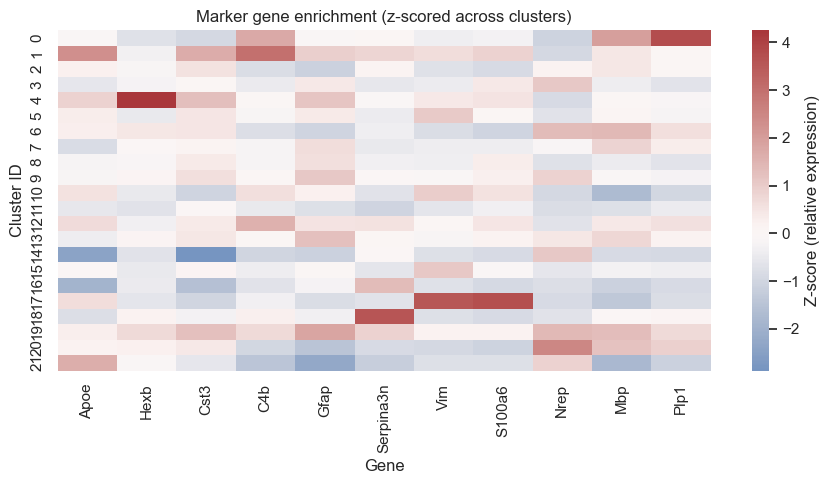

In [ ]:
leiden_results = analyze_leiden_spatial(
    combined_df_normalized,
    logger=logger,
    plot=True,
)

Research Question 3 — Relationship Between Gene Expression and Cell Type Composition

Step 1 – Quantify PIG expression and cell-type composition along distance

Bin proportion

In [ ]:
cell_proportion_analytics = process_cell_annotations(
    combined_df_normalized,
    PATH_TO_ANNOTATIONS,
    logger=logger,
    display_fn=display,
)
props, cells = cell_proportion_analytics["props"], cell_proportion_analytics["cells"]

,cell_id,cell_type,coord_X,coord_Y,predicted_label
0,aaabfoap-1,30 Astro-Epen,843.68823,608.29816,29
1,aaabonpk-1,30 Astro-Epen,851.08930,612.55554,29
2,aaadnjke-1,22 MB-HB Sero,833.55740,611.50134,21
3,aaaeilha-1,30 Astro-Epen,840.11130,616.14453,29
4,aaaenhoh-1,33 Vascular,824.70930,622.89410,32


Merged: 53895 -> 53895 rows
Annotated cells rate: 80.9%
Attention: 6332 cells with predicted_label==34 (not a valid tag).
Sum of proportions per bin: {'0-20': 1.0, '20-50': 1.0, '50-100': 1.0, '100-200': 1.0, '>200': 1.0}


Cellular composition vs distance

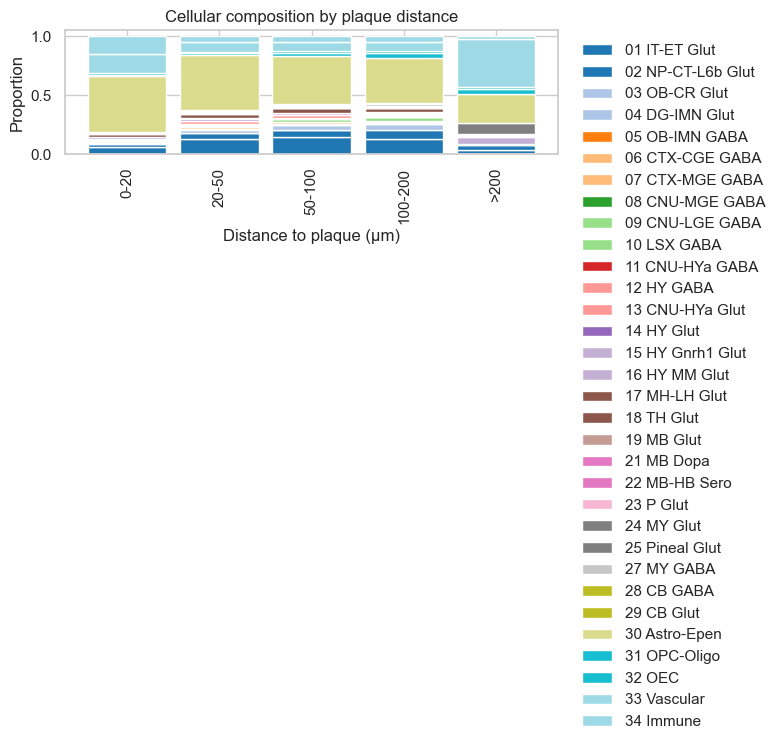

In [ ]:
pivot_prop = props.pivot_table(
    index="distance_bin", columns="cell_type", values="proportion", aggfunc="mean"
).fillna(0)
cellular_comp_by_dist(pivot_prop)

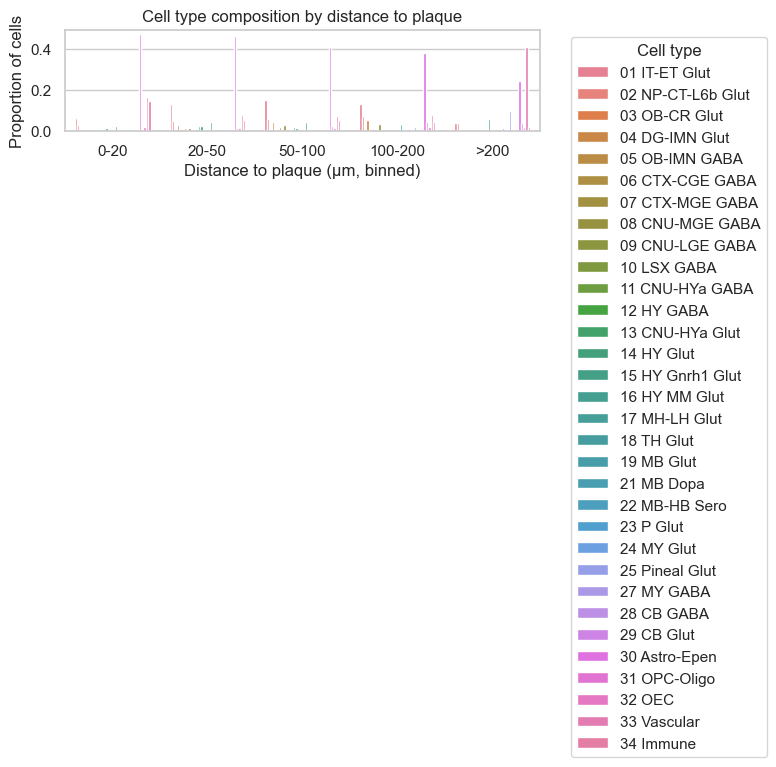

In [ ]:
cell_type_comp_by_dist(props)

Mean PIG per bin
* TODO: Fix scale

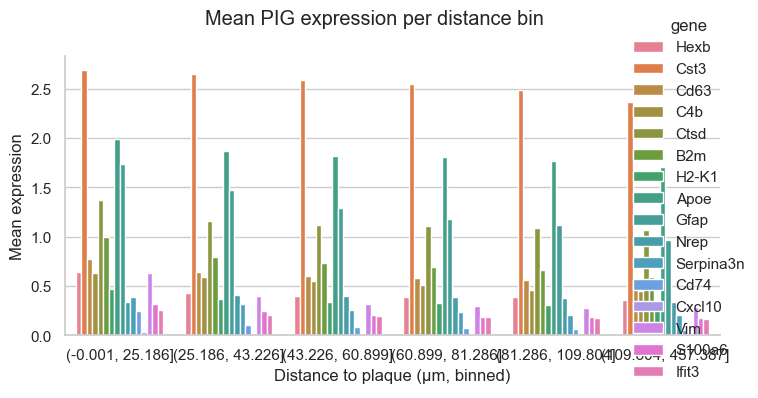

In [ ]:
mean_by_bin = combined_binned.groupby("distance_bin")[PIG_GENES].mean().reset_index()
mean_melt = mean_by_bin.melt(
    id_vars="distance_bin", value_vars=PIG_GENES, var_name="gene", value_name="mean_expr"
)
mean_exp_dist(mean_melt)

PIG curve vs distance

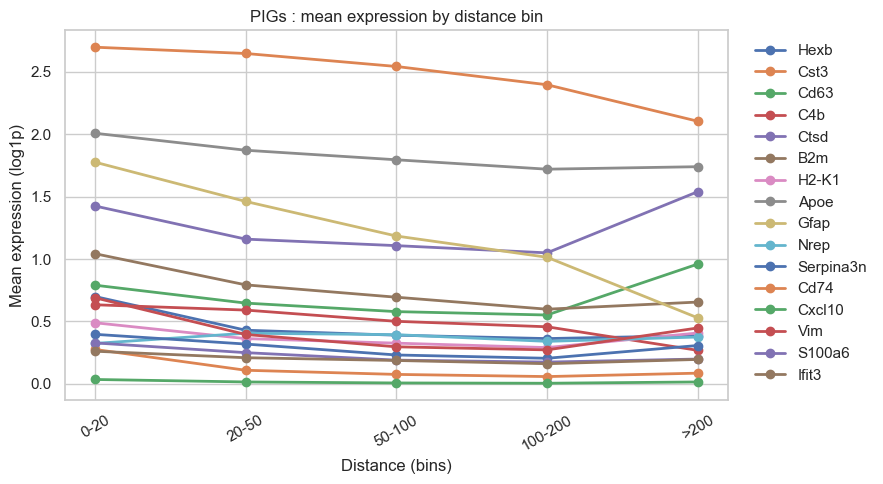

In [ ]:
mean_by_bin = cells.groupby("distance_bin")[PIG_GENES].mean().reset_index()
pig_expr_by_dist(mean_by_bin, PIG_GENES)

Heatmap correlation PIG vs composition

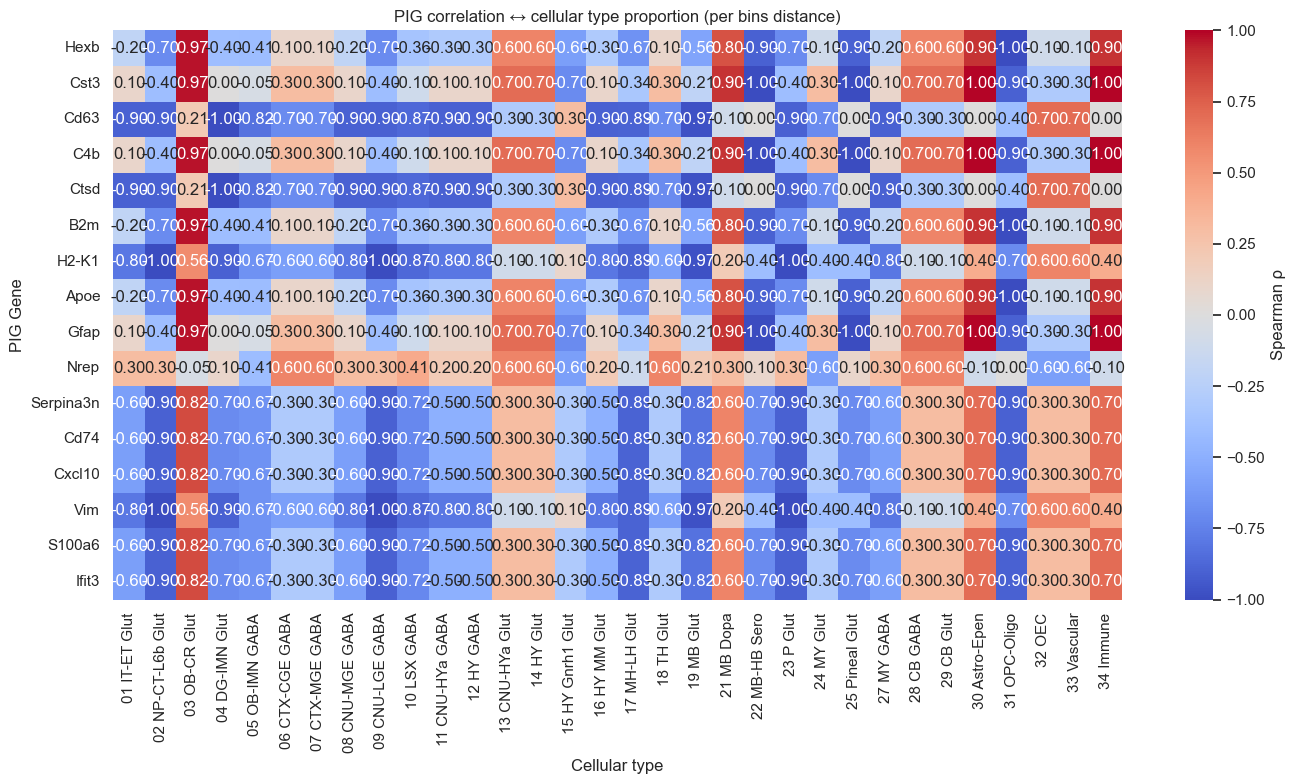

In [ ]:
# Align matrices on same bins
pig_mat = mean_by_bin.set_index("distance_bin")[PIG_GENES]
prop_mat = pivot_prop.loc[pig_mat.index]  # align index
pig_comp_heatmap(pig_mat, prop_mat, PIG_GENES)

Regression analysis : do composition explain PIG (above distance) ?  
All genes regression

In [ ]:
apoe_summary_text, gene_coefs, binned_stats, cells, agg, bin_order = (
    analyze_plaque_distance_effects(
        cells,
        PIG_GENES,
        logger=logger,
    )
)

Setting 6332 rows with predicted_label == 34 to NA in cell_type.
Creating 'broad_type' by simplifying 'cell_type'.

                            OLS Regression Results                            
Dep. Variable:              Q('Apoe')   R-squared:                       0.212
Model:                            OLS   Adj. R-squared:                  0.212
Method:                 Least Squares   F-statistic:                     2901.
Date:                Thu, 30 Oct 2025   Prob (F-statistic):               0.00
Time:                        20:54:22   Log-Likelihood:                -59281.
No. Observations:               53895   AIC:                         1.186e+05
Df Residuals:                   53889   BIC:                         1.186e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.

In [ ]:
interactive_comp_pig_regression(agg, PIG_GENES, bin_order)

Saved to figures/pig_by_distance_interactive.html


Research Question 4

X shape: (53895, 347)
y shape: (53895,)
Target NaN count: 0
Train shape: (43116, 347), Test shape: (10779, 347)
Mean of first 5 genes (train, after scaling): [ 6.99591656e-16  4.40345207e-16 -1.39686842e-15  2.67344658e-15
 -3.24268243e-16]
Std  of first 5 genes (train, after scaling): [1. 1. 1. 1. 1.]
Running LASSO
Running ELASTICNET
Running RF
Running XGB
Model performance summary created.


,model,train_r2,test_r2,alpha,l1_ratio
0,lasso,0.178874,0.173418,0.079446,NaN
1,elasticnet,0.178877,0.173481,0.082324,0.9
2,rf,0.225236,0.187433,NaN,NaN
3,xgb,0.478434,0.257721,NaN,NaN


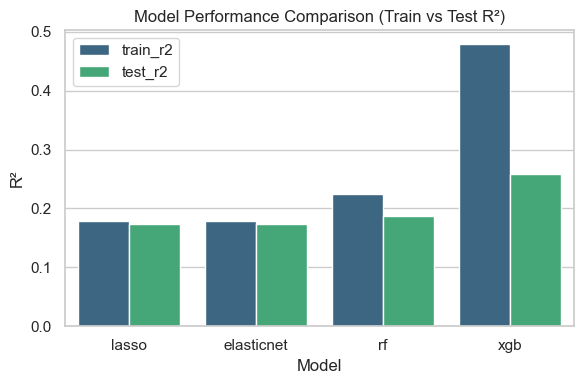

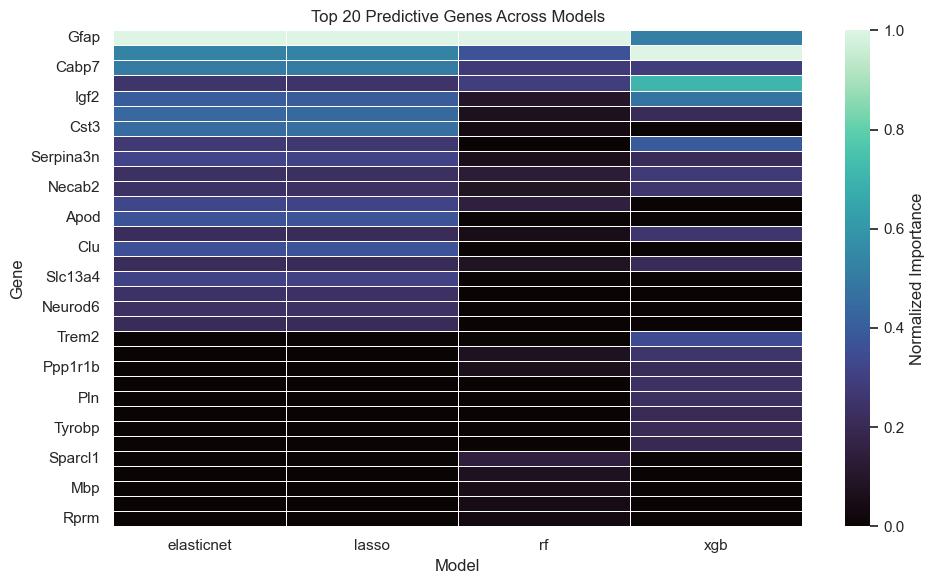

Top genes for XGB: ['Spag16', 'Lyz2', 'Gfap', 'Igf2', 'Strip2']


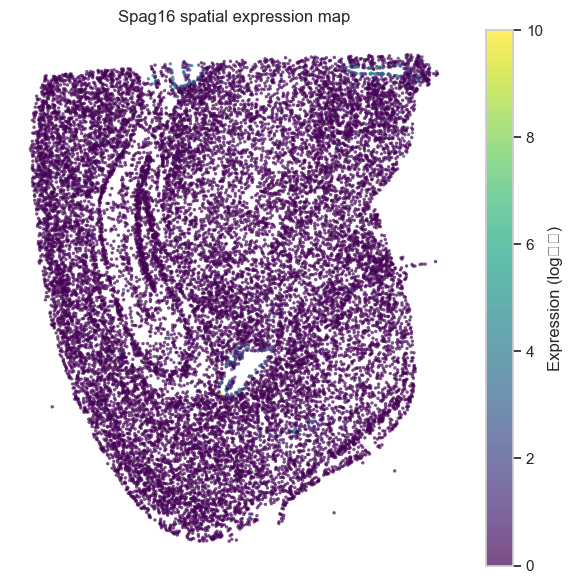

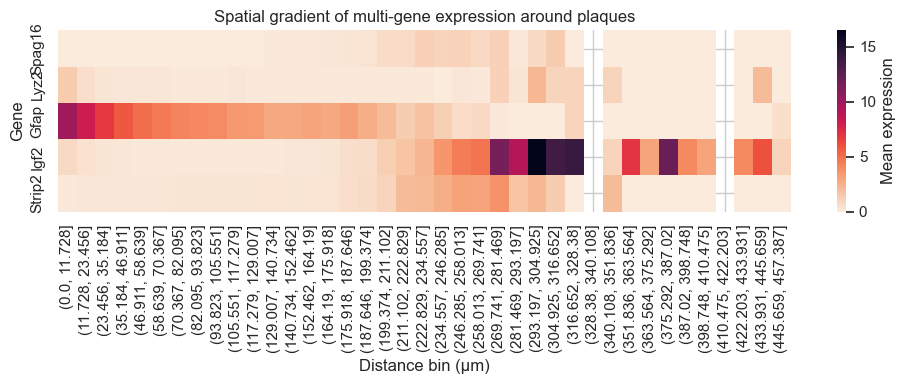

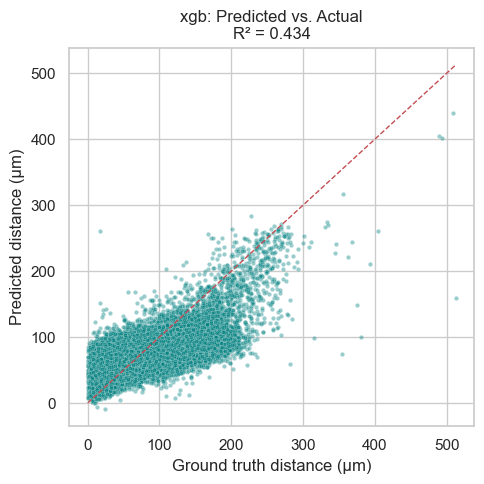

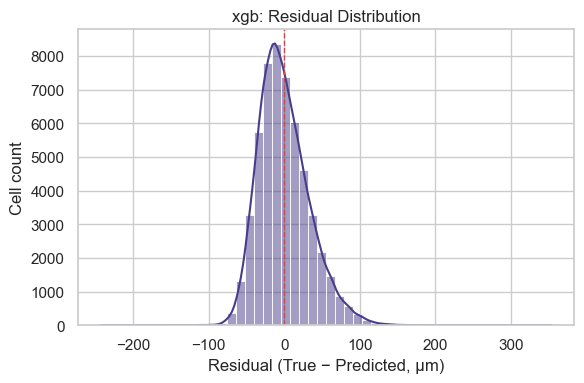

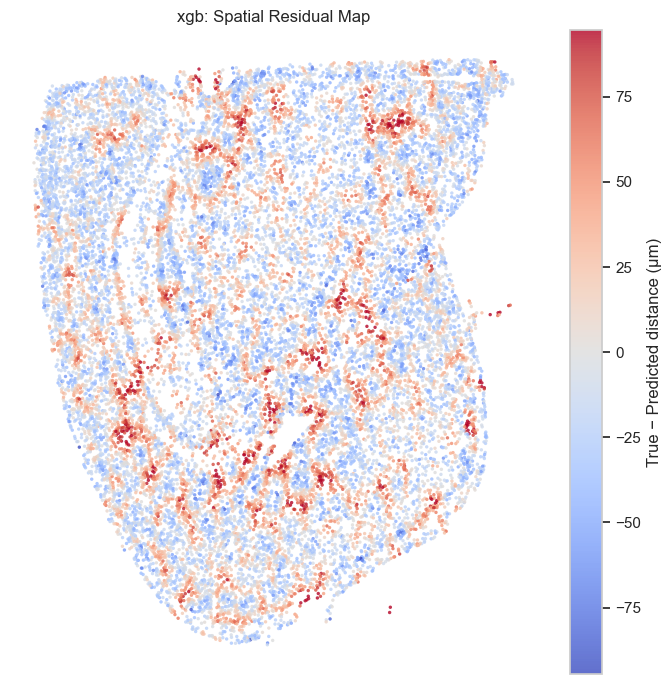

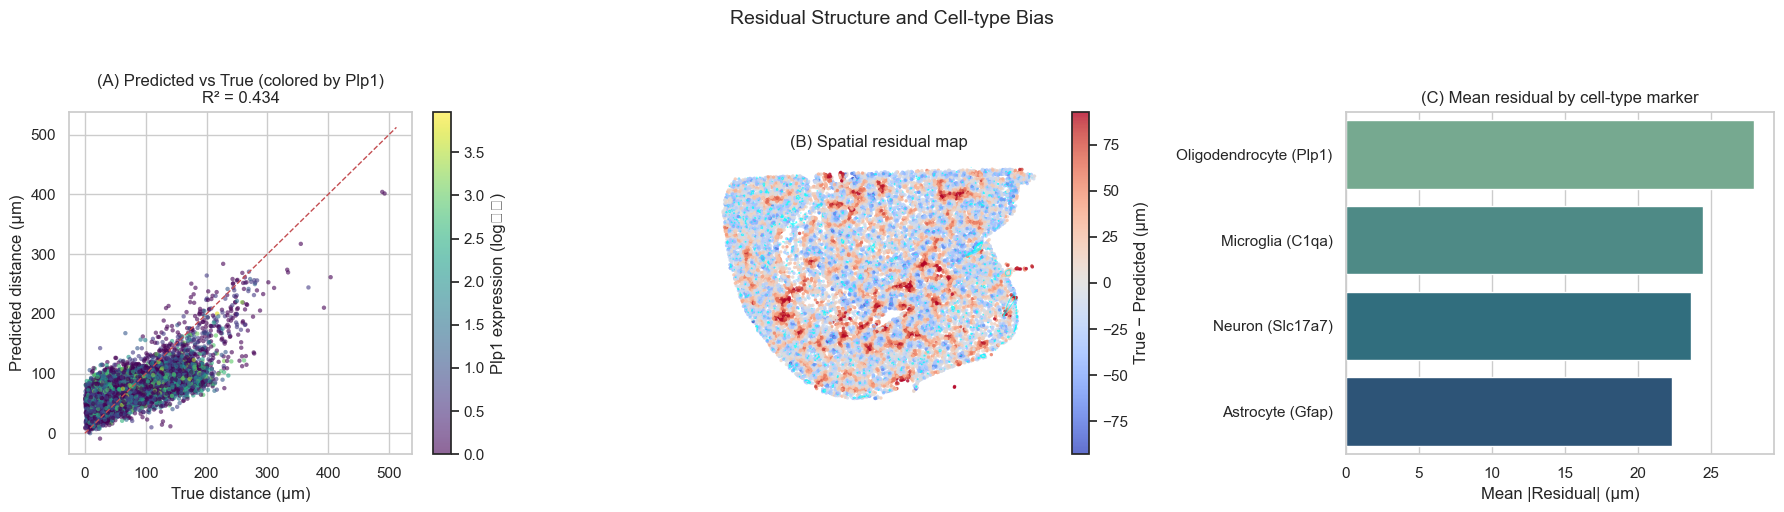

Plp1       0.544923
Apod       0.356740
Mobp       0.316862
Cnp        0.274840
Gjc3       0.118130
Gatm       0.117122
Opalin     0.078425
Mbp        0.061217
Igf2       0.049487
Sox10      0.038458
Zfp536     0.026537
Itgb4      0.025285
Gsn        0.023793
Olig2      0.013556
Slc13a4    0.008628
dtype: float64

Gene modeling pipeline completed.


In [ ]:
model_runners = {
    "lasso": pm.run_lasso,
    "elasticnet": pm.run_elasticnet,
    "rf": pm.run_rf,
    "xgb": pm.run_xgb,
}
out = run_gene_distance_modeling(
    cells_with_distances=cells_with_distances,
    gene_cols=gene_cols,
    model_runners=model_runners,
    best_model_name="xgb",
    # pass your plotting callables to enable plotting
    plot_model_performance=plot_model_performance,
    plot_top_gene_importances=plot_top_gene_importances,
    plot_spatial_overlay=plot_spatial_overlay,
    plot_multi_gene_signature=plot_multi_gene_signature,
    plot_pred_vs_true=plot_pred_vs_true,
    plot_residual_hist=plot_residual_hist,
    plot_spatial_residual_map=plot_spatial_residual_map,
    plot_residual_figure=plot_residual_figure,
    plaques_poly=plaques_poly,
    logger=logger,
    display_fn=display,
)